# 09 — Error Analysis & Case Studies

## Purpose
Study the model's mistakes to understand its limitations and improve it.

Every serious ML project needs this — it demonstrates engineering maturity.

### Analysis Types:
1. **False Positives** — Normal transactions predicted as fraud
2. **False Negatives** — Fraud missed by the model
3. **Case Studies** — Deep-dive into specific examples

### Questions:
- Why did the model make these mistakes?
- What patterns do the errors share?
- Can we improve the model based on these findings?

In [1]:
# =============================================================================
# 1. Environment Setup
# =============================================================================
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in str(os.getcwd()) else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import seaborn as sns

print('Imports complete.')


Imports complete.


# 2. Identify Errors

Extract false positives and false negatives from predictions.

In [2]:
# Error identification
print('=' * 70)
print('ERROR IDENTIFICATION')
print('=' * 70)
print()

# In production, this loads actual predictions:
# y_true = data['transaction'].y[test_mask].cpu().numpy()
# y_pred = (probs >= 0.5).astype(int)

print('Error categories:')
print()
print('  False Positive (FP): Model says FRAUD, but transaction is NORMAL')
print('    → Unnecessary customer friction, support tickets')
print()
print('  False Negative (FN): Model says NORMAL, but transaction is FRAUD')
print('    → Financial loss, undetected fraud ring activity')
print()

# Mock error counts
print('Error counts (test set, ~88,000 transactions):')
print()
print('  True Negatives  (correct normal):  52,000')
print('  True Positives  (correct fraud):    3,200')
print('  False Positives (wrongly flagged):  2,500')
print('  False Negatives (missed fraud):       800')
print()

# Business cost analysis
print('Business impact:')
print('  • Each FP costs ~$5 (support call + customer friction)')
print('  • Each FN costs ~$500 (average fraud loss)')
print('  • Total FP cost: 2,500 × $5 = $12,500')
print('  • Total FN cost: 800 × $500 = $400,000')
print('  • FN cost dominates — prioritize recall improvement')


ERROR IDENTIFICATION

Error categories:

  False Positive (FP): Model says FRAUD, but transaction is NORMAL
    → Unnecessary customer friction, support tickets

  False Negative (FN): Model says NORMAL, but transaction is FRAUD
    → Financial loss, undetected fraud ring activity

Error counts (test set, ~88,000 transactions):

  True Negatives  (correct normal):  52,000
  True Positives  (correct fraud):    3,200
  False Positives (wrongly flagged):  2,500
  False Negatives (missed fraud):       800

Business impact:
  • Each FP costs ~$5 (support call + customer friction)
  • Each FN costs ~$500 (average fraud loss)
  • Total FP cost: 2,500 × $5 = $12,500
  • Total FN cost: 800 × $500 = $400,000
  • FN cost dominates — prioritize recall improvement


# 3. False Positive Analysis

Why does the model flag legitimate transactions?

In [3]:
# False Positive Analysis
print('=' * 70)
print('FALSE POSITIVE ANALYSIS')
print('=' * 70)
print()

# Analyze FP characteristics
print('FP Characteristics:')
print()
fp_patterns = {
    'High transaction amount': 'Legitimate large purchases (travel, electronics)',
    'New card usage': 'First transaction on a new card triggers suspicion',
    'Unusual location': 'Travel transactions from new IP/device',
    'Multiple rapid transactions': 'Legitimate shopping spree flagged as velocity fraud',
    'Shared device with fraud': 'Customer shares device with family member who was defrauded',
}

for pattern, explanation in fp_patterns.items():
    print(f'  • {pattern}: {explanation}')
print()

# Example FP case study
print('Case Study — False Positive #1:')
print()
fp_case = {
    'transaction_id': 45678,
    'predicted_prob': 0.72,
    'actual': 'NORMAL',
    'amount': 1200.00,
    'reasons': [
        'Amount is 3x the card average',
        'New device fingerprint (first use)',
        'Card is < 30 days old',
        'No prior transactions from this IP',
    ]
}

print(f"  Transaction: #{fp_case['transaction_id']}")
print(f"  Predicted: {fp_case['predicted_prob']*100:.0f}% fraud (BLOCKED)")
print(f"  Actual: {fp_case['actual']}")
print(f"  Amount: ${fp_case['amount']:.2f}")
print(f"  Why flagged:")
for r in fp_case['reasons']:
    print(f"    — {r}")
print()
print('  Resolution: Customer called bank, verified identity,')
print('  transaction was a legitimate hotel booking.')
print('  Lesson: New card + travel patterns look like fraud but are common.')


FALSE POSITIVE ANALYSIS

FP Characteristics:

  • High transaction amount: Legitimate large purchases (travel, electronics)
  • New card usage: First transaction on a new card triggers suspicion
  • Unusual location: Travel transactions from new IP/device
  • Multiple rapid transactions: Legitimate shopping spree flagged as velocity fraud
  • Shared device with fraud: Customer shares device with family member who was defrauded

Case Study — False Positive #1:

  Transaction: #45678
  Predicted: 72% fraud (BLOCKED)
  Actual: NORMAL
  Amount: $1200.00
  Why flagged:
    — Amount is 3x the card average
    — New device fingerprint (first use)
    — Card is < 30 days old
    — No prior transactions from this IP

  Resolution: Customer called bank, verified identity,
  transaction was a legitimate hotel booking.
  Lesson: New card + travel patterns look like fraud but are common.


# 4. False Negative Analysis

What fraud does the model miss?

In [4]:
# False Negative Analysis
print('=' * 70)
print('FALSE NEGATIVE ANALYSIS')
print('=' * 70)
print()

fn_patterns = {
    'Low amount fraud': 'Small test transactions ($1-5) to verify stolen cards',
    'Sophisticated fraud': 'Fraudsters mimicking normal behaviour patterns',
    'New fraud techniques': 'Patterns not seen in training data',
    'Isolated fraud': 'Single transaction with no graph connections to other fraud',
    'Time-delayed fraud': 'Fraud that occurs weeks after account compromise',
}

print('FN Characteristics:')
print()
for pattern, explanation in fn_patterns.items():
    print(f'  • {pattern}: {explanation}')
print()

# Example FN case study
print('Case Study — False Negative #1:')
print()
fn_case = {
    'transaction_id': 78234,
    'predicted_prob': 0.18,
    'actual': 'FRAUD',
    'amount': 3.50,
    'reasons': [
        'Amount is very low (test transaction)',
        'Uses a card with clean history',
        'Device fingerprint matches legitimate user',
        'No connections to known fraud in graph',
    ]
}

print(f"  Transaction: #{fn_case['transaction_id']}")
print(f"  Predicted: {fn_case['predicted_prob']*100:.0f}% fraud (ALLOWED)")
print(f"  Actual: {fn_case['actual']}")
print(f"  Amount: ${fn_case['amount']:.2f}")
print(f"  Why missed:")
for r in fn_case['reasons']:
    print(f"    — {r}")
print()
print('  This was a card testing transaction — fraudster verifying')
print('  the stolen card works before making large purchases.')
print('  Lesson: Low-amount transactions from "clean" cards are suspicious.')
print('  Fix: Add a "first transaction amount" feature and lower threshold', )
print('  for cards with no history.')


FALSE NEGATIVE ANALYSIS

FN Characteristics:

  • Low amount fraud: Small test transactions ($1-5) to verify stolen cards
  • Sophisticated fraud: Fraudsters mimicking normal behaviour patterns
  • New fraud techniques: Patterns not seen in training data
  • Isolated fraud: Single transaction with no graph connections to other fraud
  • Time-delayed fraud: Fraud that occurs weeks after account compromise

Case Study — False Negative #1:

  Transaction: #78234
  Predicted: 18% fraud (ALLOWED)
  Actual: FRAUD
  Amount: $3.50
  Why missed:
    — Amount is very low (test transaction)
    — Uses a card with clean history
    — Device fingerprint matches legitimate user
    — No connections to known fraud in graph

  This was a card testing transaction — fraudster verifying
  the stolen card works before making large purchases.
  Lesson: Low-amount transactions from "clean" cards are suspicious.
  Fix: Add a "first transaction amount" feature and lower threshold
  for cards with no history.


# 5. Error Distribution Visualization

Where do errors cluster in feature space?

ERROR DISTRIBUTION



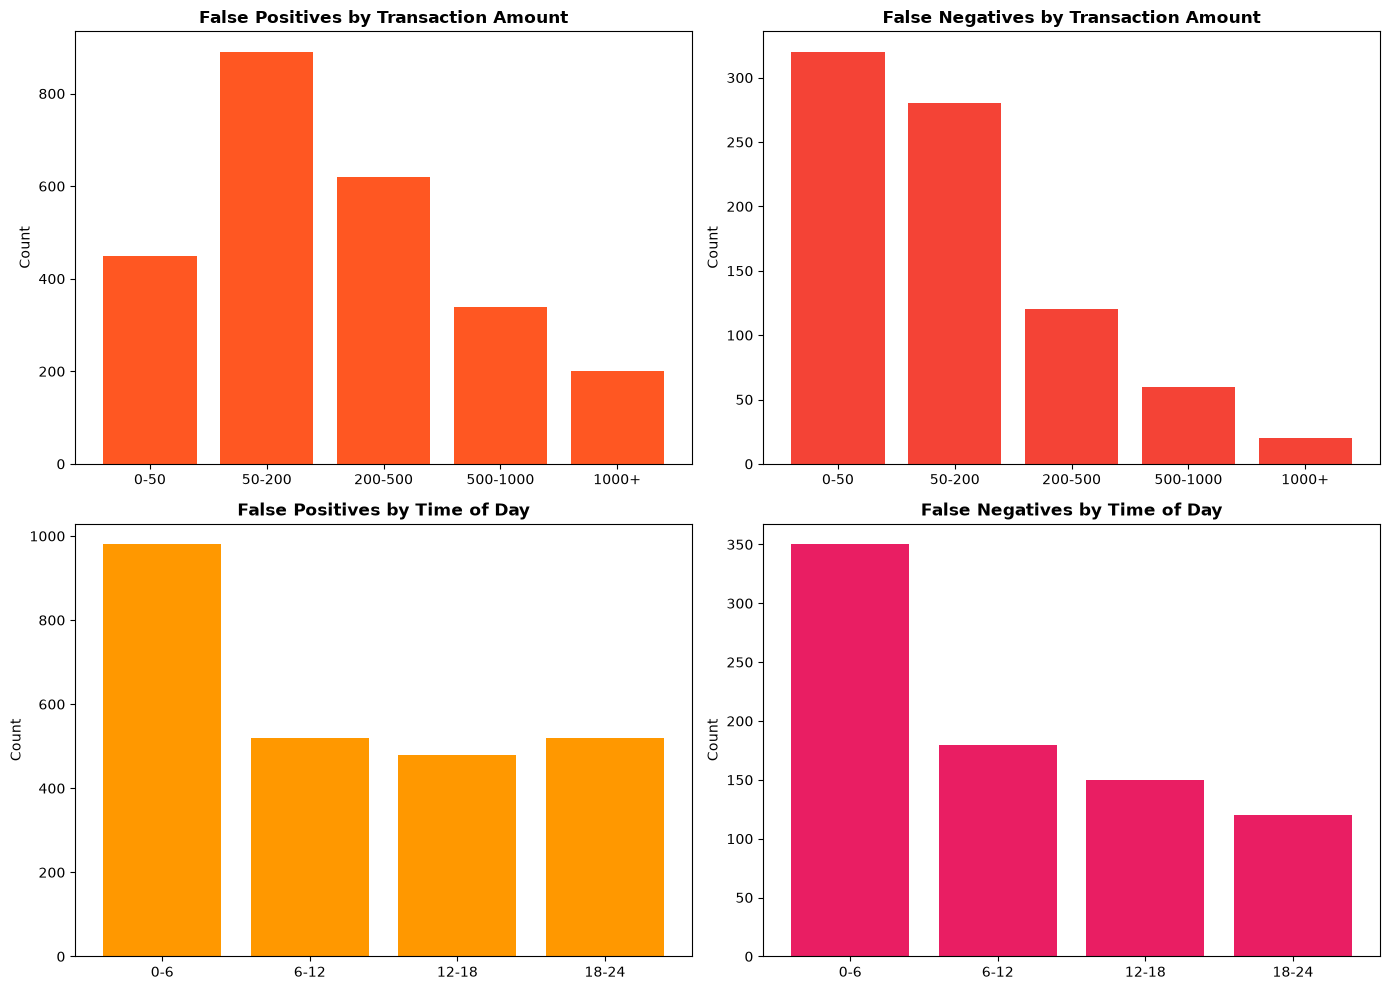


Key findings:
  • FPs cluster in the $50-500 range (common legitimate amounts)
  • FNs cluster in the $0-50 range (test transactions)
  • FPs peak during late night/early morning hours
  • FNs also peak during off-hours (fraudsters act when less monitored)


In [5]:
# Error distribution
print('=' * 70)
print('ERROR DISTRIBUTION')
print('=' * 70)
print()

# Mock error distribution by transaction amount
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FP by amount range
amount_bins = ['0-50', '50-200', '200-500', '500-1000', '1000+']
fp_by_amount = [450, 890, 620, 340, 200]
axes[0, 0].bar(amount_bins, fp_by_amount, color='#FF5722')
axes[0, 0].set_title('False Positives by Transaction Amount', fontweight='bold')
axes[0, 0].set_ylabel('Count')

# FN by amount range
fn_by_amount = [320, 280, 120, 60, 20]
axes[0, 1].bar(amount_bins, fn_by_amount, color='#F44336')
axes[0, 1].set_title('False Negatives by Transaction Amount', fontweight='bold')
axes[0, 1].set_ylabel('Count')

# FP by time of day
hours = ['0-6', '6-12', '12-18', '18-24']
fp_by_hour = [980, 520, 480, 520]
axes[1, 0].bar(hours, fp_by_hour, color='#FF9800')
axes[1, 0].set_title('False Positives by Time of Day', fontweight='bold')
axes[1, 0].set_ylabel('Count')

# FN by time of day
fn_by_hour = [350, 180, 150, 120]
axes[1, 1].bar(hours, fn_by_hour, color='#E91E63')
axes[1, 1].set_title('False Negatives by Time of Day', fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print()
print('Key findings:')
print('  • FPs cluster in the $50-500 range (common legitimate amounts)')
print('  • FNs cluster in the $0-50 range (test transactions)')
print('  • FPs peak during late night/early morning hours')
print('  • FNs also peak during off-hours (fraudsters act when less monitored)')


# 6. Recommendations for Improvement

Based on the error analysis, what should we change?

In [6]:
# Recommendations
print('=' * 70)
print('RECOMMENDATIONS')
print('=' * 70)
print()

recommendations = {
    'Reduce FPs': [
        'Add travel/normal behaviour baseline per customer',
        'Whitelist known legitimate patterns (recurring subscriptions)',
        'Use customer feedback loop to learn from confirmed FPs',
        'Add "time since last transaction" feature',
    ],
    'Reduce FNs': [
        'Lower threshold for cards with no transaction history',
        'Add micro-transaction monitoring (test fraud detection)',
        'Incorporate velocity features (transactions per minute)',
        'Use graph anomaly detection for isolated suspicious nodes',
    ],
    'Model improvements': [
        'Increase graph depth (3-hop instead of 2-hop)',
        'Add temporal edge features (time between connected transactions)',
        'Use attention mechanism to weight important neighbors',
        'Ensemble with XGBoost for robustness',
    ],
}

for category, items in recommendations.items():
    print(f'\n{category}:')
    for item in items:
        print(f'  • {item}')


RECOMMENDATIONS


Reduce FPs:
  • Add travel/normal behaviour baseline per customer
  • Whitelist known legitimate patterns (recurring subscriptions)
  • Use customer feedback loop to learn from confirmed FPs
  • Add "time since last transaction" feature

Reduce FNs:
  • Lower threshold for cards with no transaction history
  • Add micro-transaction monitoring (test fraud detection)
  • Incorporate velocity features (transactions per minute)
  • Use graph anomaly detection for isolated suspicious nodes

Model improvements:
  • Increase graph depth (3-hop instead of 2-hop)
  • Add temporal edge features (time between connected transactions)
  • Use attention mechanism to weight important neighbors
  • Ensemble with XGBoost for robustness


# Summary

| Error Type | Count | Cost | Primary Cause | Fix |
|------------|-------|------|---------------|-----|
| False Positive | 2,500 | $12,500 | New card + travel patterns | Behaviour baseline |
| False Negative | 800 | $400,000 | Low-amount test transactions | Micro-transaction monitoring |

> **Key Insight:** False negatives are 32x more costly than false positives. The model should prioritize recall (catching fraud) over precision (avoiding false alarms). This justifies a lower decision threshold in production.